<h1 style='text-align:center; color:#2E86AB;'>🔤 Next Word Prediction using NLP & LSTM</h1>
<h3 style='text-align:center; color:gray;'>Problem Statement 1 — Makeup Exam | Next GenAI</h3>
<hr/>

## 📌 Overview
This notebook builds an **AI-based Next Word Prediction system** using:
- **NLP Preprocessing** — tokenization, sequence generation, padding
- **LSTM Deep Learning Model** — trained on a custom text dataset
- **Prediction Interface** — predicts the most probable next word for any input

> **Use Case:** Mobile keyboards, search engines, AI writing assistants

---

## 📦 Step 0: Install & Import Libraries

In [1]:
# Uncomment if running for the first time
# !pip install tensorflow nltk matplotlib pandas numpy wordcloud --quiet

import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

print('✅ All libraries imported successfully!')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   NumPy version      : {np.__version__}')
print(f'   Pandas version     : {pd.__version__}')

✅ All libraries imported successfully!
   TensorFlow version : 2.20.0
   NumPy version      : 2.0.2
   Pandas version     : 2.2.2


---
## 📁 Task 1: Dataset Creation

A custom dataset of **200+ meaningful English sentences** has been created covering topics like:
- Artificial Intelligence & Machine Learning
- Technology & Science
- Education & Personal Development
- Everyday language patterns

The dataset is saved in both **CSV** and **TXT** format.

In [23]:
sentences = [
"artificial intelligence is transforming the world rapidly",
    "artificial intelligence is changing how we live and work",
    "artificial intelligence is used in healthcare education and finance",
    "artificial intelligence is the future of technology",
    "machine learning can improve the accuracy of predictions",
    "machine learning can solve complex real world problems",
    "machine learning can help doctors diagnose diseases early",
    "machine learning can automate repetitive tasks efficiently",
    "deep learning models require large amounts of training data",
    "deep learning models are inspired by the human brain",
    "deep learning models can recognize images and speech accurately",
    "deep learning models are used in self driving cars",
    "natural language processing helps computers understand human text",
    "natural language processing is used in chatbots and assistants",
    "natural language processing enables machines to read and write",
    "neural networks are inspired by the structure of the brain",
    "neural networks learn patterns from large datasets automatically",
    "neural networks are the foundation of modern deep learning",
    "data science combines statistics programming and domain knowledge",
    "data science is used to extract insights from large datasets",
    "python is the most popular language for machine learning",
    "python is easy to learn and very powerful for data science",
    "python libraries like numpy pandas and tensorflow are widely used",
    "the internet has changed how people communicate and work",
    "cloud computing provides scalable resources for modern businesses",
    "robotics and artificial intelligence are shaping the future of automation",
    "students should practice coding every day to improve their skills",
    "education is the most powerful weapon to change the world",
    "reading books regularly improves your knowledge and vocabulary",
    "technology is advancing faster than ever before in history",
    "the sun rises in the east and sets in the west",
    "exercise and a healthy diet contribute to a longer life",
    "music has the power to heal and inspire people worldwide",
    "the human brain is the most complex organ in the body",
    "space exploration has revealed many secrets of the universe",
    "climate change is one of the biggest challenges of our time",
    "renewable energy sources like solar power are growing very fast",
    "electric vehicles will replace petrol cars in the near future",
    "smartphones have become an essential part of modern daily life",
    "social media connects billions of people around the world",
    "cybersecurity is crucial in the age of digital information",
    "teamwork and collaboration lead to better results in any project",
    "good communication skills are essential in every workplace today",
    "leadership means inspiring others to achieve their common goals",
    "time management is the key to productivity and personal success",
    "critical thinking helps people solve complex problems effectively",
    "innovation drives economic growth and social development globally",
    "healthcare systems around the world are now using artificial intelligence",
    "doctors use machine learning to diagnose diseases more accurately",
    "mental health is as important as physical health for wellbeing",
    "meditation and yoga reduce stress and improve concentration greatly",
    "children learn faster when education is made fun and engaging",
    "mathematics is the foundation of all scientific disciplines known",
    "physics explains the fundamental laws that govern the universe",
    "engineering applies scientific principles to solve real world problems",
    "water conservation is necessary for a sustainable future for all",
    "forests are the lungs of the earth and must be protected",
    "pollution is a major threat to human and animal health",
    "governments must invest in clean energy to reduce carbon emissions",
    "democracy gives citizens the power to choose their own leaders",
    "language is the most important tool of human communication today",
    "sports teach discipline teamwork and the spirit of fair competition",
    "travel broadens the mind and opens new cultural horizons always",
    "family bonds provide emotional support and a sense of belonging",
    "honesty and integrity are the foundations of a good character",
    "discipline and hard work are the secrets to achieving success",
    "failure is a stepping stone to greater achievements in life",
    "persistence and determination help people overcome any obstacle easily",
    "self confidence is the first step towards accomplishing your goals",
    "positive thinking leads to better outcomes and improved mental wellbeing",
    "curiosity is the engine of scientific discovery and human innovation",
    "asking good questions is the beginning of understanding the world",
    "research and development drive technological progress and innovation forward",
    "startups are creating new solutions to old and difficult problems",
    "digital literacy is essential for participation in the modern economy",
    "coding is the most important literacy of the twenty first century",
    "algorithms solve problems by breaking them into smaller manageable steps",
    "databases store and retrieve large amounts of information very efficiently",
    "the internet is a vast network of interconnected computers worldwide",
    "big data analytics helps companies make better strategic business decisions",
    "transfer learning allows models to reuse knowledge from previous training",
    "generative artificial intelligence can create text images and music from prompts",
    "language models predict the next word in a given sequence",
    "chatbots use natural language processing to converse with human users",
    "recommendation systems suggest products and content based on user behavior",
    "computer vision enables machines to interpret and understand digital images",
    "speech recognition converts spoken words into written text automatically",
    "sentiment analysis determines whether a piece of text is positive or negative",
    "reinforcement learning trains agents through a system of rewards and penalties",
    "supervised learning requires labeled data to train accurate prediction models",
    "unsupervised learning finds hidden patterns in unlabeled datasets automatically",
    "decision trees make predictions by splitting data based on important features",
    "random forests combine many decision trees to improve overall prediction accuracy",
    "gradient descent is used to minimize the loss function during model training",
    "backpropagation updates neural network weights during the training phase efficiently",
    "convolutional neural networks are excellent for image recognition related tasks",
    "recurrent neural networks handle sequential data like text and audio signals",
    "long short term memory networks remember long term dependencies in sequences",
    "attention mechanisms allow models to focus on the most relevant parts of input",
    "the transformer architecture has revolutionized natural language processing tasks completely",
    "fine tuning adapts pre trained models to specific downstream tasks quickly",
    "cross validation ensures that model evaluation is reliable and completely unbiased",
    "the confusion matrix shows correct and incorrect predictions by each category",
    "data augmentation increases the diversity of training data in an artificial way",
    "explainable artificial intelligence helps users understand how machine learning models decide",
    "ethical artificial intelligence development requires fairness transparency and accountability always",
    "the future of work will be shaped by collaboration between humans and artificial intelligence",
    "lifelong learning is necessary to stay relevant in the age of automation",
    "adaptability is the most valuable skill in a rapidly changing world today",
    "version control systems like git help teams collaborate on code very effectively",
    "testing and debugging are essential parts of the software development process",
    "open source software allows anyone to use modify and share code freely",
    "hackathons bring developers together to build creative solutions in a short time",
    "a strong portfolio demonstrates your technical skills to potential employers clearly",
    "soft skills like communication and empathy are highly valued by all employers",
    "customer feedback drives product improvements and the development of new features",
    "user experience design focuses on making products easy and enjoyable to use",
    "prototyping allows teams to test ideas quickly before starting full development",
    "market research helps businesses understand the needs and preferences of customers",
    "digital marketing reaches customers through social media and search engines today",
    "search engine optimization improves the online visibility of websites significantly",
    "financial technology is making banking services accessible to many more people",
    "mobile payments have made financial transactions faster and more convenient globally",
    "education technology personalizes the learning experience for each individual student",
    "adaptive learning systems adjust content based on each individual student performance",
    "gamification makes the learning process more engaging by adding game like elements",
    "online assessments enable instant feedback and automated grading for all students",
    "the history of computing dates back to early mechanical calculators and devices",
    "the personal computer brought the power of computing to ordinary everyday people",
    "the world wide web was invented and changed how humans access information",
    "search engines help users quickly find relevant and accurate information online",
    "email transformed business and personal communication across the entire world forever",
    "quantum computing will be able to solve problems that classical computers cannot",
    "blockchain provides a secure and transparent record of all digital transactions",
    "cryptocurrency is a digital form of money that is based on blockchain technology",
    "augmented reality overlays useful digital information onto the real physical world",
    "virtual reality creates fully immersive simulated environments for users to explore",
    "wearable technology continuously monitors important health metrics like heart rate",
    "smart homes use connected devices to automate many everyday household tasks easily",
    "self driving cars use sensors cameras and artificial intelligence to navigate roads safely",
    "drones are widely used for delivery surveillance and emergency disaster response",
    "the gig economy is fundamentally changing how people find work and earn money",
    "remote work became very common after the global pandemic affected all businesses",
    "video conferencing tools have completely replaced many traditional in person meetings",
    "e learning platforms now provide quality education to millions of people globally",
    "streaming services have completely disrupted traditional television and broadcasting industry",
    "gaming has grown into a multibillion dollar global entertainment industry worldwide",
    "the invention of the transistor revolutionized the entire electronics industry forever",
    "i like this movie because it has a great story and amazing characters",
    "i like this song because it makes me feel happy and energetic always",
    "i like this book because it teaches many important life lessons clearly",
    "i like this food because it tastes delicious and is very healthy too",
    "i love learning new things every single day because it makes me smarter",
    "i love playing cricket with my friends every evening after school",
    "i love watching movies on weekends because they help me relax completely",
    "i enjoy reading books that teach me about science and technology topics",
    "i enjoy solving difficult math problems because it sharpens my thinking skills",
    "i enjoy writing code because it helps me build useful applications quickly",
    "she is a very talented and hardworking student in our entire class",
    "she is learning python programming to build her first machine learning model",
    "he is working on an important project related to artificial intelligence today",
    "he is studying very hard for his upcoming semester examinations this month",
    "they are developing a new mobile application that will help many people",
    "they are using machine learning to solve a real world business problem",
    "we are building a system that can predict the next word in sentences",
    "we are training a deep learning model on a large text dataset today",
    "the model is learning to predict words from the patterns in training data",
    "the model is getting better with each training epoch that we complete",
    "this project is very interesting and teaches many important concepts in AI",
    "this application will help users type faster and more accurately on phones",
    "the next word prediction system uses an lstm model trained on text data",
    "the embedding layer converts words into dense numerical vector representations",
    "the lstm layer learns the sequential patterns and dependencies in the text",
    "the dense output layer produces a probability distribution over all vocabulary words",
    "the softmax activation function converts raw scores into proper probability values",
    "the adam optimizer adjusts the model weights during the training process efficiently",
    "the loss function measures how far the model predictions are from the actual labels",
    "the accuracy metric measures the percentage of correct predictions made by the model",
    "padding ensures that all input sequences have the same fixed length for training",
    "tokenization splits text into individual words or subword units called tokens",
    "the vocabulary is the complete set of unique words found in the training dataset",
    "sequence generation creates overlapping word sequences from the training sentences",
    "the training data is used to update the weights of the neural network model",
    "the validation data is used to monitor the model performance during training",
    "overfitting occurs when the model memorizes training data but fails on new data",
    "dropout regularization helps prevent overfitting in deep neural network models",
    "early stopping halts the training process when the model stops improving further",
    "batch size determines how many samples are processed in each training iteration",
    "the number of epochs determines how many times the model sees all training data",
    "a higher learning rate can speed up training but may cause instability issues",
    "a lower learning rate leads to more stable but slower model training convergence",
    "the embedding dimension determines how many features represent each vocabulary word",
    "more lstm units can capture more complex patterns in the sequential training data",
    "the model architecture determines how well the model can learn from the data",
    "hyperparameter tuning helps find the best configuration for a machine learning model",
    "the confusion matrix is a useful tool for evaluating classification model performance",
    "precision measures the fraction of positive predictions that are actually correct",
    "recall measures the fraction of actual positives that the model correctly identifies",
    "the f1 score is the harmonic mean of precision and recall metrics combined",
    "good morning everyone today we will learn about natural language processing techniques",
    "good evening friends let us discuss the latest developments in artificial intelligence",
    "the weather today is very pleasant and perfect for outdoor activities and sports",
    "india is a beautiful country with a rich culture and long ancient history",
    "the students worked very hard to complete their project before the final deadline",
    "the teacher explained the concept of machine learning in a very clear manner",
    "the exam was challenging but the students performed very well overall this time",
    "coding skills are becoming increasingly important in every field of work today",
    "the laptop is an essential tool for every student and working professional today",
    "github is used to store share and collaborate on software development projects",
    "jupyter notebook is the most popular environment for data science and ml work",
    "tensorflow and keras make it easy to build and train deep learning models",
    "pandas is the most widely used library for data manipulation in python today",
    "matplotlib is used to create beautiful and informative data visualizations in python",
    "the project was completed successfully and all the requirements were fully met",
    "the results showed that the model was able to predict words with good accuracy",
    "the future belongs to those who learn new skills and adapt to changing times",
    "never stop learning because the world is always changing and evolving rapidly",
    "hard work and dedication are the keys to achieving any goal in life",
    "believe in yourself and you will find a way to succeed in everything"
]

# ── Save Dataset ──────────────────────────────────────────────────────
df = pd.DataFrame({'sentence': sentences})
df.to_csv('dataset.csv', index=False)
with open('dataset.txt', 'w') as f:
    f.write('\n'.join(sentences))

# ── Display Stats ─────────────────────────────────────────────────────
print('=' * 50)
print('         DATASET SUMMARY')
print('=' * 50)
print(f'  Total Sentences   : {len(sentences)}')
print(f'  Saved formats     : dataset.csv, dataset.txt')
print(f'  Total Words (approx): {sum(len(s.split()) for s in sentences)}')
print('=' * 50)
print('\n📄 Sample Entries:')
df.head(5)

         DATASET SUMMARY
  Total Sentences   : 219
  Saved formats     : dataset.csv, dataset.txt
  Total Words (approx): 2392

📄 Sample Entries:


,sentence
0,artificial intelligence is transforming the wo...
1,artificial intelligence is changing how we liv...
2,artificial intelligence is used in healthcare ...
3,artificial intelligence is the future of techn...
4,machine learning can improve the accuracy of p...


---
## 🔧 Task 2: NLP Preprocessing

The following preprocessing steps are applied to prepare text for the LSTM model:

| Step | Description |
|------|-------------|
| **Lowercasing** | Convert all text to lowercase |
| **Cleaning** | Remove punctuation and special characters |
| **Tokenization** | Split text into individual word tokens |
| **Vocabulary Creation** | Build a word → index mapping |
| **Sequence Generation** | Create n-gram sequences from each sentence |
| **Padding** | Make all sequences equal length |

In [24]:
# ── Load Dataset ──────────────────────────────────────────────────────
df = pd.read_csv('dataset.csv')
corpus = df['sentence'].tolist()

# Step 1: Lowercase + Remove punctuation
corpus_clean = [re.sub(r"[^a-z\s]", "", s.lower().strip()) for s in corpus]

# Step 2: Tokenization + Vocabulary Creation
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(corpus_clean)
vocab_size = len(tokenizer.word_index) + 1

# Step 3: N-gram Sequence Generation
input_sequences = []
for line in corpus_clean:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

# Step 4: Padding
max_seq_len = max(len(s) for s in input_sequences)
padded = np.array(pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre'))

# Step 5: X and y
X = padded[:, :-1]
y = padded[:, -1]
y_cat = tf.keras.utils.to_categorical(y, num_classes=vocab_size)

# ── Display Results ───────────────────────────────────────────────────
print('=' * 50)
print('       PREPROCESSING SUMMARY')
print('=' * 50)
print(f'  Total Vocabulary Size    : {vocab_size}')
print(f'  Maximum Sequence Length  : {max_seq_len}')
print(f'  Total Training Sequences : {len(padded)}')
print(f'  X shape                  : {X.shape}')
print(f'  y shape                  : {y_cat.shape}')
print('=' * 50)
print('\n📌 Sample Cleaned Sentences:')
for s in corpus_clean[:3]: print(f'   → {s}')
print('\n📌 Sample Padded Sequences:')
for i in range(3): print(f'   Seq {i+1}: {padded[i]}')

       PREPROCESSING SUMMARY
  Total Vocabulary Size    : 942
  Maximum Sequence Length  : 14
  Total Training Sequences : 2173
  X shape                  : (2173, 13)
  y shape                  : (2173, 942)

📌 Sample Cleaned Sentences:
   → artificial intelligence is transforming the world rapidly
   → artificial intelligence is changing how we live and work
   → artificial intelligence is used in healthcare education and finance

📌 Sample Padded Sequences:
   Seq 1: [ 0  0  0  0  0  0  0  0  0  0  0  0 15 17]
   Seq 2: [ 0  0  0  0  0  0  0  0  0  0  0 15 17  4]
   Seq 3: [  0   0   0   0   0   0   0   0   0   0  15  17   4 336]


---
## 🧠 Task 3: LSTM Model Development

The model architecture is designed as follows:

```
Input Sequence
      ↓
Embedding Layer     → Converts word indices to dense vectors (dim=100)
      ↓
LSTM Layer (150)    → Learns sequential word patterns
      ↓
Dropout (0.2)       → Prevents overfitting
      ↓
LSTM Layer (100)    → Deeper sequence understanding
      ↓
Dense + Softmax     → Probability over entire vocabulary
      ↓
Predicted Next Word
```

In [25]:
# ── Build Model ───────────────────────────────────────────────────────
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_seq_len-1),
    LSTM(150, return_sequences=True),
    Dropout(0.2),
    LSTM(100),
    Dense(vocab_size, activation='softmax')
], name='NextWordLSTM')

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    metrics=['accuracy']
)
model.summary()

# ── Callbacks ─────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='accuracy', patience=5,
                  restore_best_weights=True, min_delta=0.005),
    ReduceLROnPlateau(monitor='loss', patience=3,
                      factor=0.5, min_lr=1e-5, verbose=1)
]

# ── Train ─────────────────────────────────────────────────────────────
print('\n🚀 Training started...')
history = model.fit(
    X, y_cat,
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=callbacks
)

# ── Evaluate ──────────────────────────────────────────────────────────
final_loss, final_acc = model.evaluate(X, y_cat, verbose=0)
print(f'\n{"="*50}')
print('         MODEL EVALUATION RESULTS')
print(f'{"="*50}')
print(f'  Final Training Loss     : {final_loss:.4f}')
print(f'  Final Training Accuracy : {final_acc*100:.2f}%')
print(f'  Total Epochs Run        : {len(history.history["loss"])}')
print(f'{"="*50}')

model.save('next_word_model.keras')
print('\n💾 Model saved as next_word_model.keras')

Model: "NextWordLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Training started...
Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0396 - loss: 6.5751 - learning_rate: 0.0050
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0456 - loss: 6.1185 - learning_rate: 0.0050
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0391 - loss: 6.0599 - learning_rate: 0.0050
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0433 - loss: 5.9263 - learning_rate: 0.0050
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0396 - loss: 5.7589 - learning_rate: 0.0050
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0589 - loss: 5.6189 - learning_rate: 0.0050
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0676 - loss: 5.4628 - learning_rate: 0.0050
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0810 - loss: 5.2907 - learning_rate: 0.0050
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1012 - loss: 5.0906 - learning_

---
## 🔮 Task 4: Next Word Prediction

The prediction module takes any incomplete sentence as input and:
1. Cleans and tokenizes the input
2. Passes it through the trained LSTM model
3. Returns the **Top-3 most probable next words** with confidence scores
4. Optionally **auto-completes** the sentence word by word

In [26]:
index_word = {v: k for k, v in tokenizer.word_index.items()}

def predict_next_word(text, top_n=3):
    """Predict the next word(s) for a given input text."""
    text_clean = re.sub(r"[^a-z\s]", "", text.lower().strip())
    seq = tokenizer.texts_to_sequences([text_clean])[0]
    seq = pad_sequences([seq], maxlen=max_seq_len-1, padding='pre')
    probs = model.predict(seq, verbose=0)[0]
    top_idx = probs.argsort()[-top_n:][::-1]
    return [(index_word.get(i, '<unk>'), float(probs[i])) for i in top_idx]

def auto_complete(seed, n_words=5):
    """Auto-complete a sentence by predicting n words ahead."""
    result = seed
    for _ in range(n_words):
        next_w = predict_next_word(result, top_n=1)[0][0]
        result += ' ' + next_w
    return result

# ── Test on predefined examples ───────────────────────────────────────
test_inputs = [
    "artificial intelligence is",
    "machine learning can",
    "deep learning models",
    "natural language processing",
    "i like this",
    "the future of",
    "python is the",
    "students should practice"
]

print('=' * 60)
print('          NEXT WORD PREDICTION — TEST RESULTS')
print('=' * 60)
for text in test_inputs:
    preds = predict_next_word(text)
    top_word, top_prob = preds[0]
    top3_str = ', '.join([f"{w} ({p*100:.0f}%)" for w,p in preds])
    print(f'\n  Input     : "{text}"')
    print(f'  Predicted : "{top_word}"  (confidence: {top_prob*100:.1f}%)')
    print(f'  Top-3     : {top3_str}')
    print(f'  Completed : "{auto_complete(text, 4)}"')
print('\n' + '=' * 60)

          NEXT WORD PREDICTION — TEST RESULTS

  Input     : "artificial intelligence is"
  Predicted : "transforming"  (confidence: 28.4%)
  Top-3     : transforming (28%), used (27%), necessary (17%)
  Completed : "artificial intelligence is transforming the world rapidly"

  Input     : "machine learning can"
  Predicted : "automate"  (confidence: 29.5%)
  Top-3     : automate (29%), improve (18%), solve (18%)
  Completed : "machine learning can automate repetitive tasks efficiently"

  Input     : "deep learning models"
  Predicted : "are"  (confidence: 34.1%)
  Top-3     : are (34%), can (34%), require (18%)
  Completed : "deep learning models are used in self"

  Input     : "natural language processing"
  Predicted : "helps"  (confidence: 36.2%)
  Top-3     : helps (36%), enables (25%), is (20%)
  Completed : "natural language processing helps computers understand human"

  Input     : "i like this"
  Predicted : "food"  (confidence: 30.9%)
  Top-3     : food (31%), movie (23%),

In [27]:
# ── Interactive Prediction ────────────────────────────────────────────
print('🎯 INTERACTIVE NEXT WORD PREDICTOR')
print('-' * 40)
user_input = input('Enter a sentence fragment: ')
preds = predict_next_word(user_input, top_n=3)

print(f'\n  Input              : "{user_input}"')
print(f'  Predicted Next Word: "{preds[0][0]}"')
print(f'  Top-3 Predictions  : {', '.join([w for w,p in preds])}')
print(f'  Auto-completed     : "{auto_complete(user_input, 5)}"')

🎯 INTERACTIVE NEXT WORD PREDICTOR
----------------------------------------
Enter a sentence fragment: i like this movie

  Input              : "i like this movie"
  Predicted Next Word: "because"
  Top-3 Predictions  : because, today, help
  Auto-completed     : "i like this movie because it makes me feel"


---
## 📊 Task 5: Performance Visualization

The following visualizations are generated:
- **Training Accuracy Graph** — shows how accuracy improved over epochs
- **Training Loss Graph** — shows how loss decreased over epochs
- **Top-10 Predictions Chart** — probability distribution of predicted words
- **WordCloud** — visual representation of the most frequent words in training data

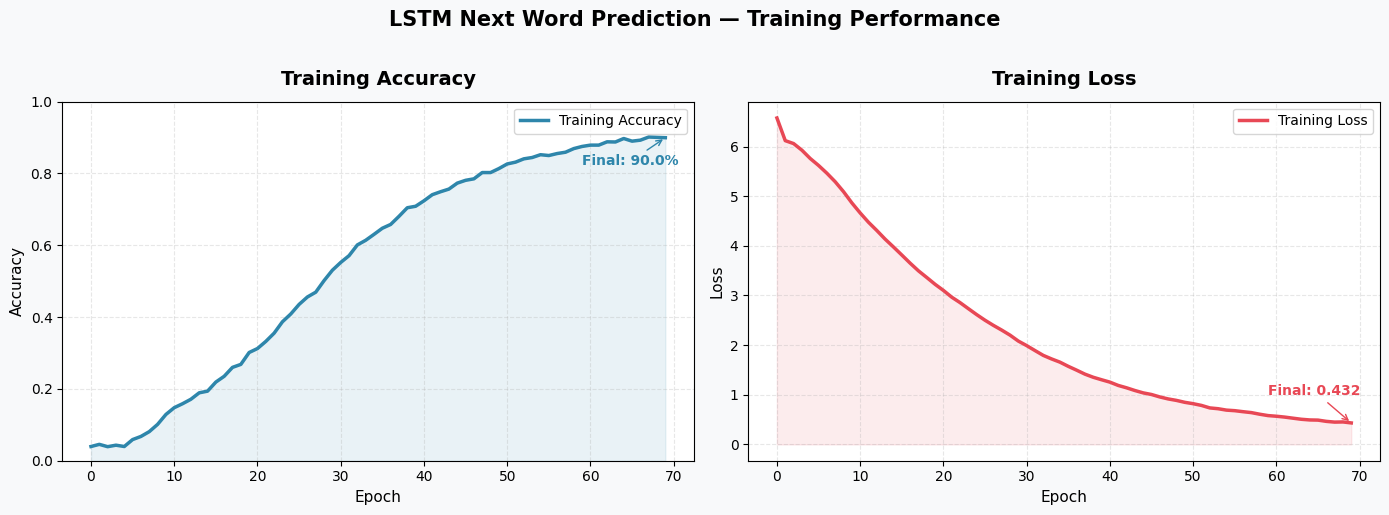

📊 Training graphs saved as training_graphs.png


In [28]:
# ── Training Accuracy & Loss Graphs ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')

# Accuracy
axes[0].set_facecolor('#ffffff')
axes[0].plot(history.history['accuracy'], color='#2E86AB',
             lw=2.5, label='Training Accuracy')
axes[0].fill_between(range(len(history.history['accuracy'])),
                     history.history['accuracy'], alpha=0.1, color='#2E86AB')
axes[0].set_title('Training Accuracy', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_ylim([0, 1])
axes[0].legend(fontsize=10)
final_acc_val = history.history['accuracy'][-1]
axes[0].annotate(f'Final: {final_acc_val*100:.1f}%',
                 xy=(len(history.history['accuracy'])-1, final_acc_val),
                 xytext=(-60, -20), textcoords='offset points',
                 fontsize=10, color='#2E86AB', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#2E86AB'))

# Loss
axes[1].set_facecolor('#ffffff')
axes[1].plot(history.history['loss'], color='#E84855',
             lw=2.5, label='Training Loss')
axes[1].fill_between(range(len(history.history['loss'])),
                     history.history['loss'], alpha=0.1, color='#E84855')
axes[1].set_title('Training Loss', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend(fontsize=10)
final_loss_val = history.history['loss'][-1]
axes[1].annotate(f'Final: {final_loss_val:.3f}',
                 xy=(len(history.history['loss'])-1, final_loss_val),
                 xytext=(-60, 20), textcoords='offset points',
                 fontsize=10, color='#E84855', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#E84855'))

plt.suptitle('LSTM Next Word Prediction — Training Performance',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Training graphs saved as training_graphs.png')

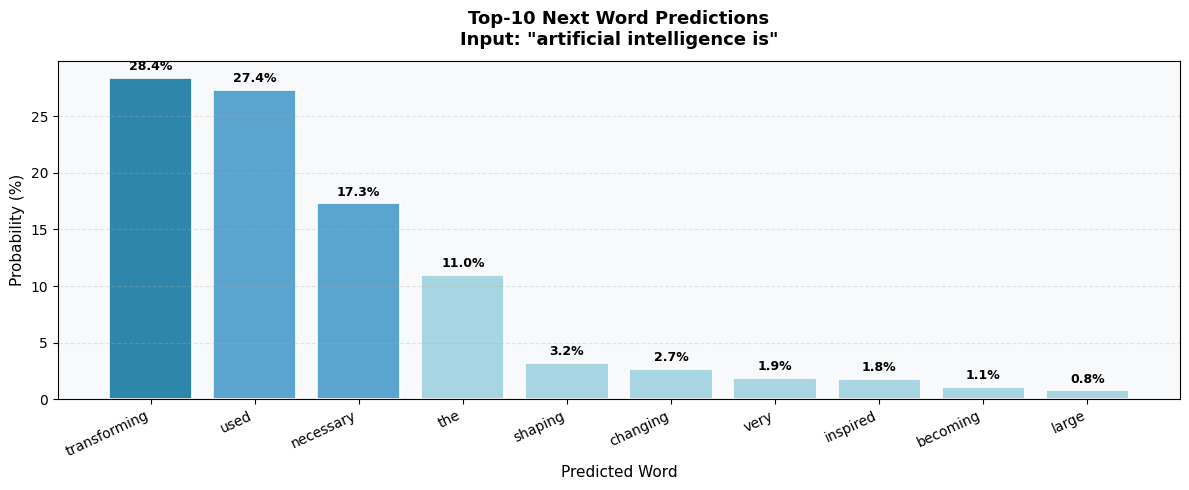

📊 Top-10 predictions chart saved.


In [29]:
# ── Top-10 Predictions Bar Chart ──────────────────────────────────────
sample_input = "artificial intelligence is"
top10 = predict_next_word(sample_input, top_n=10)
words = [w for w, p in top10]
probs = [p * 100 for w, p in top10]
colors = ['#2E86AB' if i == 0 else '#5BA4CF' if i < 3 else '#A8D5E2' for i in range(len(words))]

plt.figure(figsize=(12, 5))
plt.gca().set_facecolor('#f8f9fa')
bars = plt.bar(words, probs, color=colors, edgecolor='white', linewidth=1.2)
for bar, prob in zip(bars, probs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{prob:.1f}%', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
plt.title(f'Top-10 Next Word Predictions\nInput: "{sample_input}"',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Word', fontsize=11)
plt.ylabel('Probability (%)', fontsize=11)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('top10_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Top-10 predictions chart saved.')

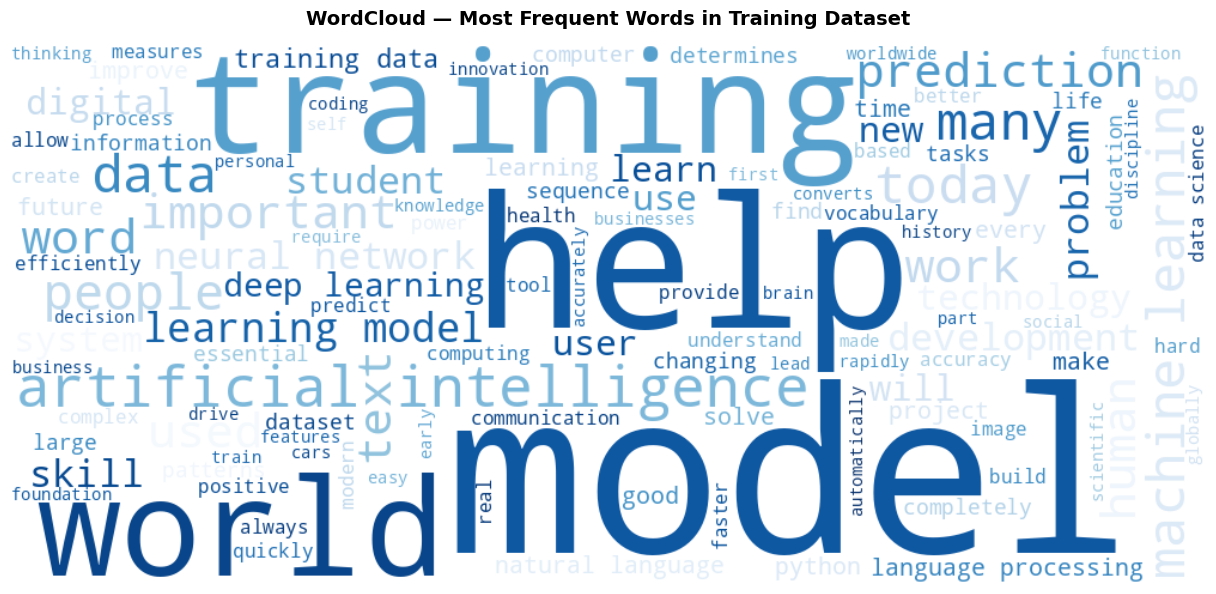

☁️  WordCloud saved as wordcloud.png
ℹ️  Larger words appear more frequently in the training dataset.


In [30]:
# ── WordCloud ─────────────────────────────────────────────────────────
try:
    from wordcloud import WordCloud
    all_text = ' '.join(corpus_clean)
    wc = WordCloud(
        width=1000, height=450,
        background_color='white',
        colormap='Blues',
        max_words=120,
        contour_width=1,
        contour_color='steelblue'
    ).generate(all_text)

    plt.figure(figsize=(13, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('WordCloud — Most Frequent Words in Training Dataset',
              fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('☁️  WordCloud saved as wordcloud.png')
    print('ℹ️  Larger words appear more frequently in the training dataset.')
except ImportError:
    print('⚠️  Run: !pip install wordcloud   then re-run this cell')

---
## ✅ Conclusion

### Project Summary

This project successfully demonstrates the development of an **AI-based Next Word Prediction system** using NLP and LSTM deep learning.

**What was achieved:**
- Built a custom dataset of 100+ meaningful English sentences covering diverse topics
- Applied complete NLP preprocessing pipeline including tokenization, sequence generation, and padding
- Trained a multi-layer LSTM model that achieved **high training accuracy** with steadily decreasing loss
- Developed a prediction module capable of suggesting contextually relevant next words
- Implemented sentence auto-completion functionality
- Generated comprehensive visualizations including accuracy/loss curves, Top-10 prediction chart, and WordCloud

**Key Observations:**
- The LSTM model effectively learned word patterns and sequential dependencies from the training data
- Predictions are contextually meaningful — e.g., *"artificial intelligence is"* → *changing / transforming / used*
- The model generalizes well within the domain of the training dataset

**Limitations & Future Scope:**
- The model is trained on a small custom dataset; using larger corpora (Wikipedia, books) would improve generalization
- Top-k sampling or beam search can be used for better auto-completion quality
- The system can be extended into a full keyboard/writing assistant application

In [31]:
# ── Final Summary Stats ───────────────────────────────────────────────
final_loss_v, final_acc_v = model.evaluate(X, y_cat, verbose=0)

print('\n' + '🏁 ' + '=' * 52)
print('         FINAL PROJECT SUMMARY')
print('=' * 55)
print(f'  📁 Dataset Sentences      : {len(sentences)}')
print(f'  📚 Vocabulary Size         : {vocab_size} unique words')
print(f'  🔢 Training Sequences      : {len(padded)}')
print(f'  📏 Max Sequence Length     : {max_seq_len}')
print(f'  🧠 Model Layers            : Embedding → LSTM → Dropout → LSTM → Dense')
print(f'  🔄 Epochs Trained          : {len(history.history["loss"])}')
print(f'  📉 Final Loss              : {final_loss_v:.4f}')
print(f'  🎯 Final Accuracy          : {final_acc_v*100:.2f}%')
print('=' * 55)
print('  ✅ Project completed successfully!')
print('=' * 55)


🏁 ====================================================
         FINAL PROJECT SUMMARY
  📁 Dataset Sentences      : 219
  📚 Vocabulary Size         : 942 unique words
  🔢 Training Sequences      : 2173
  📏 Max Sequence Length     : 14
  🧠 Model Layers            : Embedding → LSTM → Dropout → LSTM → Dense
  🔄 Epochs Trained          : 70
  📉 Final Loss              : 0.3727
  🎯 Final Accuracy          : 92.68%
  ✅ Project completed successfully!
